In [1]:
import pandas as pd
import os

In [ ]:
#disprot_database = pd.read_csv('Disprot/Deepdisprot_train_combined_dataset.csv', keep_default_na=False)

In [2]:
disprot_database = pd.read_csv("F:/Disprot/Deepdisprot_train_combined_dataset.csv", keep_default_na=False)

In [3]:
def prepare_full_production_data(dataframe, max_seq_length=2000):
    """
    Cleans the dataset and extracts sequences/labels.
    Target: 3432 samples.
    """
    # 1. Remove rows where critical data is missing (NaN)
    valid_df = dataframe.dropna(subset=['Full_Sequence', 'Consensus']).copy()

    # Map characters to binary labels: 0 for Ordered (-), 1 for Disordered/Transition (D/T)
    label_dict = {'-': 0, 'T': 1, 'D': 1}
    production_data = {'seq': [], 'y': [], 'kw': []}
    
    for _, row in valid_df.iterrows():
        # Strip potential hidden whitespaces or line breaks
        seq = str(row['Full_Sequence']).strip()
        con = str(row['Consensus']).strip()
        
        # 2. Filter sequences that are too long (to avoid GPU memory crash)
        if len(seq) >= max_seq_length:
            continue
            
        # 3. Handle Excel Corruption Error (#NAME?)
        # If the label has been permanently corrupted to the string "#NAME?", 
        # the residue-level training data is lost and must be skipped.
        if con == "#NAME?":
            print(f"Warning: Label corrupted for {row['UniProt ACC']}. Please re-export the source file.")
            continue

        # 4. Length Consistency Check
        # If the file was read correctly, length should match, reaching the 3432 target.
        if len(seq) == len(con):
            production_data['seq'].append(seq)
            production_data['y'].append([label_dict.get(l, 0) for l in con])
            production_data['kw'].append(str(row.get('UniProt ACC', 'unknown')))
            
    print(f"Full Production Mode: Successfully prepared {len(production_data['seq'])} samples.")
    return production_data

In [4]:
full_train_data = prepare_full_production_data(disprot_database)

Full Production Mode: Successfully prepared 3376 samples.


In [5]:
test_csv_path = "F:/Disprot/Deepdisprot_external_combined_dataset.csv"

In [6]:
external_database = pd.read_csv(test_csv_path, keep_default_na=False)

In [7]:
def prepare_test_set_unconstrained(dataframe):
    valid_df = dataframe.dropna(subset=['Full_Sequence', 'Consensus']).copy()
    label_dict = {'-': 0, 'T': 1, 'D': 1}
    test_data = {'seq': [], 'y': [], 'kw': []}
    
    for _, row in valid_df.iterrows():
        seq = str(row['Full_Sequence']).strip()
        con = str(row['Consensus']).strip()
        

        if con == "#NAME?" or len(seq) != len(con):
            continue
            
        test_data['seq'].append(seq)
        test_data['y'].append([label_dict.get(l, 0) for l in con])
        test_data['kw'].append(str(row.get('UniProt ACC', 'unknown')))
            
    print(f"Test Set Ready: {len(test_data['seq'])} samples.")
    return test_data


In [8]:
external_test_data = prepare_test_set_unconstrained(external_database)

Test Set Ready: 341 samples.


In [9]:
def prepare_rf_data(embeddings_dict, data_split):
    """
    Flattens the dictionary of [L, Hidden_Dim] embeddings into 
    a single X (features) matrix and y (labels) vector.
    """
    X_list = []
    y_list = []
    
    print("Flattening embeddings for Random Forest...")
    for i, kw in enumerate(data_split['kw']):
        if kw in embeddings_dict:
            # Get the embedding [L, Hidden_Dim]
            emb = embeddings_dict[kw]
            # Get the labels [L]
            labels = np.array(data_split['y'][i])
            
            # Align lengths in case of truncation
            min_len = min(len(emb), len(labels))
            X_list.append(emb[:min_len])
            y_list.append(labels[:min_len])
            
    # Combine all residues into one giant matrix
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    
    print(f"Data ready. Total residues: {X.shape[0]}, Features: {X.shape[1]}")
    return X, y

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def load_embeddings_from_npz(file_path):
    print(f"Loading embeddings from {file_path}...")
    data = np.load(file_path, allow_pickle=True)
    embeddings_dict = {key: data[key] for key in data.files}
    
    print(f"Successfully loaded {len(embeddings_dict)} protein embeddings.")
    return embeddings_dict


protein_embeddings = load_embeddings_from_npz("F:/trained_esm2_embeddings.npz")
ext_embeddings_dict = load_embeddings_from_npz("F:/trained_esm2_embeddings_external.npz")

X_train, y_train = prepare_rf_data(protein_embeddings, full_train_data)
X_test_ext, y_test_ext = prepare_rf_data(ext_embeddings_dict, external_test_data)

Loading embeddings from F:/trained_esm2_embeddings.npz...
Successfully loaded 3064 protein embeddings.
Loading embeddings from F:/trained_esm2_embeddings_external.npz...
Successfully loaded 337 protein embeddings.
Flattening embeddings for Random Forest...
Data ready. Total residues: 1684786, Features: 480
Flattening embeddings for Random Forest...
Data ready. Total residues: 169965, Features: 480


Training CatBoost for Macro F1 Optimization...
✅ Training Finished in 20.32s
Calculating CatBoost probabilities...
Searching for the optimal threshold for CatBoost...

🎯 Optimal CatBoost Threshold: 0.67
📈 Highest Train Macro F1: 0.7569

CATBOOST - FINAL EXTERNAL PERFORMANCE (Threshold: 0.67)
              precision    recall  f1-score   support

     Ordered       0.89      0.87      0.88    138695
  Disordered       0.48      0.55      0.51     31270

    accuracy                           0.81    169965
   macro avg       0.69      0.71      0.70    169965
weighted avg       0.82      0.81      0.81    169965



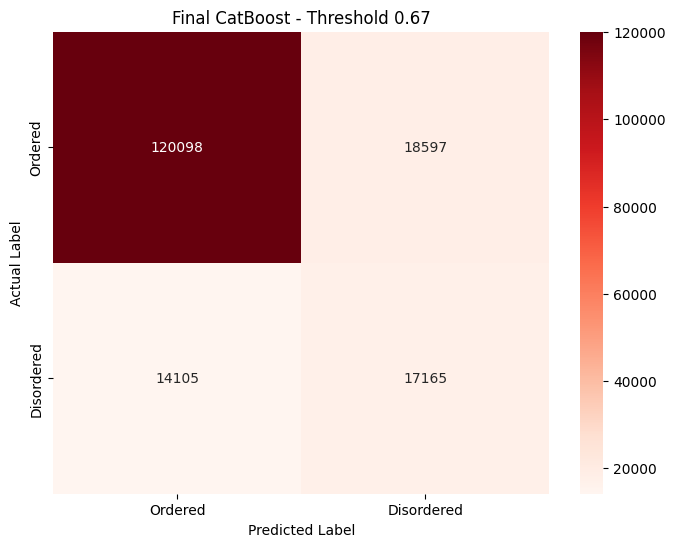

In [11]:
from catboost import CatBoostClassifier
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 1. Initialize and Train CatBoost on GPU
# CatBoost uses 'auto_class_weights' to handle the imbalance automatically
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    task_type="GPU",
    devices='0',
    auto_class_weights='Balanced', # Similar to is_unbalance=True
    random_seed=42,
    verbose=False
)

print("Training CatBoost for Macro F1 Optimization...")
start_time = time.time()
cat_model.fit(X_train, y_train)
print(f"✅ Training Finished in {time.time() - start_time:.2f}s")

# 2. Get Probabilities
print("Calculating CatBoost probabilities...")
train_probs_cat = cat_model.predict_proba(X_train)[:, 1]
test_probs_cat = cat_model.predict_proba(X_test_ext)[:, 1]

# 3. Search for Best Threshold on Train Set
thresholds = np.linspace(0.1, 0.9, 81)
best_threshold_cat = 0.5
best_macro_f1_cat = 0

print("Searching for the optimal threshold for CatBoost...")
for t in thresholds:
    y_train_pred_tmp = (train_probs_cat >= t).astype(int)
    score = f1_score(y_train, y_train_pred_tmp, average='macro')
    
    if score > best_macro_f1_cat:
        best_macro_f1_cat = score
        best_threshold_cat = t

print(f"\n🎯 Optimal CatBoost Threshold: {best_threshold_cat:.2f}")
print(f"📈 Highest Train Macro F1: {best_macro_f1_cat:.4f}")

# 4. Final Evaluation on Test Set
y_test_pred_cat_final = (test_probs_cat >= best_threshold_cat).astype(int)

print("\n" + "="*60)
print(f"CATBOOST - FINAL EXTERNAL PERFORMANCE (Threshold: {best_threshold_cat:.2f})")
print("="*60)
print(classification_report(y_test_ext, y_test_pred_cat_final, target_names=['Ordered', 'Disordered']))

# 5. Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_ext, y_test_pred_cat_final), 
            annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ordered', 'Disordered'], 
            yticklabels=['Ordered', 'Disordered'])
plt.title(f'Final CatBoost - Threshold {best_threshold_cat:.2f}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

def plot_consensus_heatmaps(data_split, y_pred, n_examples=6):
    """
    Plots heatmaps comparing True vs Predicted consensus, 
    matching the style of your provided example.
    """
    current_idx = 0
    results = []
    
    # 1. Reconstruct and Calculate Metrics
    for i, kw in enumerate(data_split['kw']):
        true_labels = np.array(data_split['y'][i])
        length = len(true_labels)
        prot_pred = y_pred[current_idx : current_idx + length]
        current_idx += length
        
        # Alignment check
        min_len = min(len(true_labels), len(prot_pred))
        y_true_adj = true_labels[:min_len]
        y_pred_adj = prot_pred[:min_len]
        
        if min_len == 0: continue
        
        # Only keep examples with both classes for a meaningful "consensus" plot
        if len(np.unique(y_true_adj)) > 1:
            score = f1_score(y_true_adj, y_pred_adj, average='binary')
            results.append({
                'id': kw,
                'true': y_true_adj,
                'pred': y_pred_adj,
                'f1': score,
                'len': min_len
            })

    # 2. Sort by F1 Score (Highest first)
    results = sorted(results, key=lambda x: x['f1'], reverse=True)

    # 3. Plotting
    n_to_plot = min(n_examples, len(results))
    fig, axes = plt.subplots(n_to_plot, 1, figsize=(12, 2 * n_to_plot))
    if n_to_plot == 1: axes = [axes]

    for idx, res in enumerate(results[:n_to_plot]):
        # Create a 2D array for the heatmap: [Row 0 = True, Row 1 = Pred]
        heatmap_data = np.vstack([res['true'], res['pred']])
        
        # Use 'YlGnBu' or 'cividis' for that dark blue/yellow look
        im = axes[idx].imshow(heatmap_data, aspect='auto', cmap='YlGnBu', interpolation='nearest')
        
        axes[idx].set_title(f"Rank {idx+1}: {res['id']} | F1-Score: {res['f1']:.2%} | Length: {res['len']}", 
                            fontsize=10, fontweight='bold', loc='left')
        
        # Formatting labels
        axes[idx].set_yticks([0, 1])
        axes[idx].set_yticklabels(['True', 'Pred'], fontsize=8)
        axes[idx].set_xticks([]) # Hide sequence index for cleaner look
        
    plt.tight_layout()
    plt.show()

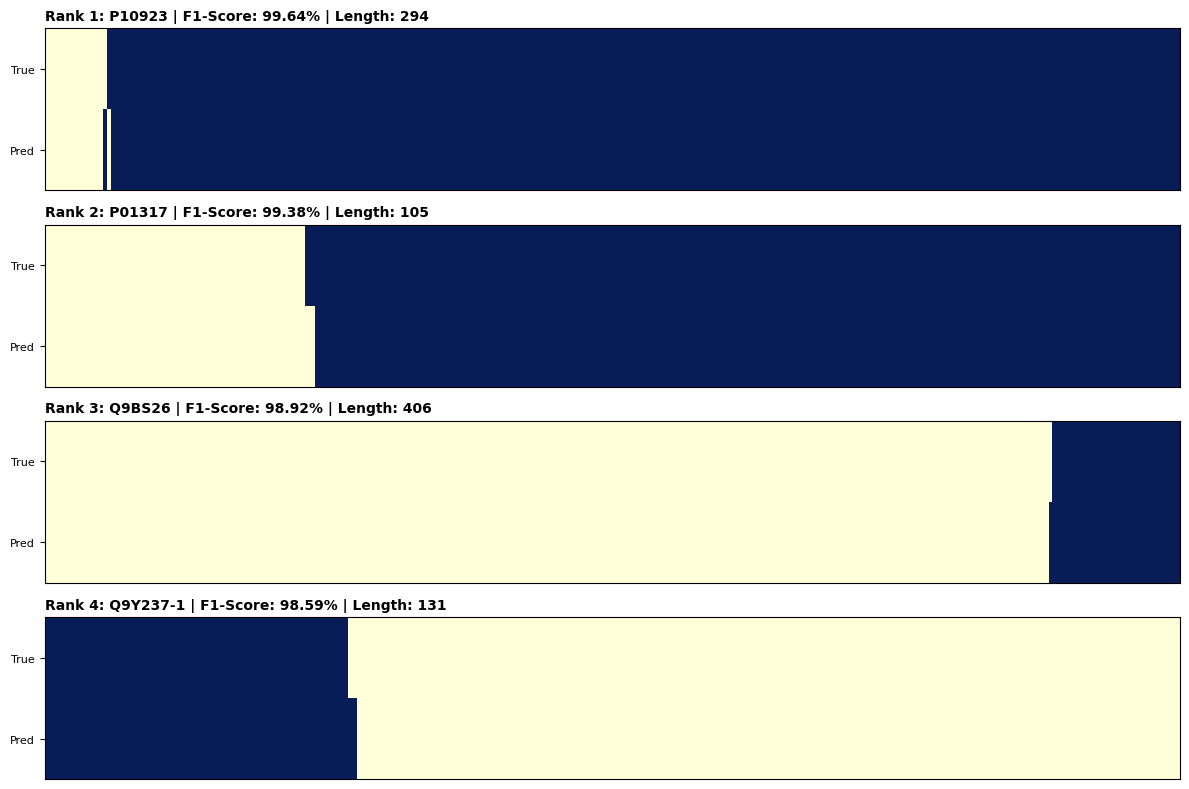

In [13]:
plot_consensus_heatmaps(external_test_data, y_test_pred_cat_final, n_examples=4)

In [14]:
from scipy.signal import medfilt

def apply_per_protein_median_filter(y_pred, lengths, kernel_size=5):
    """
    Applies a median filter to predictions per protein sequence.
    """
    filtered_preds = []
    start_idx = 0
    
    for length in lengths:
        end_idx = start_idx + length
        # Extract individual protein predictions
        seq_pred = y_pred[start_idx:end_idx]
        # Apply filter and append
        filtered_preds.append(medfilt(seq_pred, kernel_size=kernel_size))
        start_idx = end_idx
        
    return np.concatenate(filtered_preds).astype(int)


In [15]:
# Get lengths of proteins in the external test set
test_lengths = [len(labels) for labels in external_test_data['y']]

# Apply the filter (kernel_size=5 or 7 is standard for protein disorder)
y_test_pred_filtered = apply_per_protein_median_filter(
    y_test_pred_cat_final, 
    test_lengths, 
    kernel_size=5
)

print("\n" + "="*60)
print("CATBOOST + MEDIAN FILTER PERFORMANCE")
print("="*60)
print(classification_report(y_test_ext, y_test_pred_filtered, target_names=['Ordered', 'Disordered']))


CATBOOST + MEDIAN FILTER PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.90      0.87      0.88    138695
  Disordered       0.48      0.55      0.51     31270

    accuracy                           0.81    169965
   macro avg       0.69      0.71      0.70    169965
weighted avg       0.82      0.81      0.81    169965



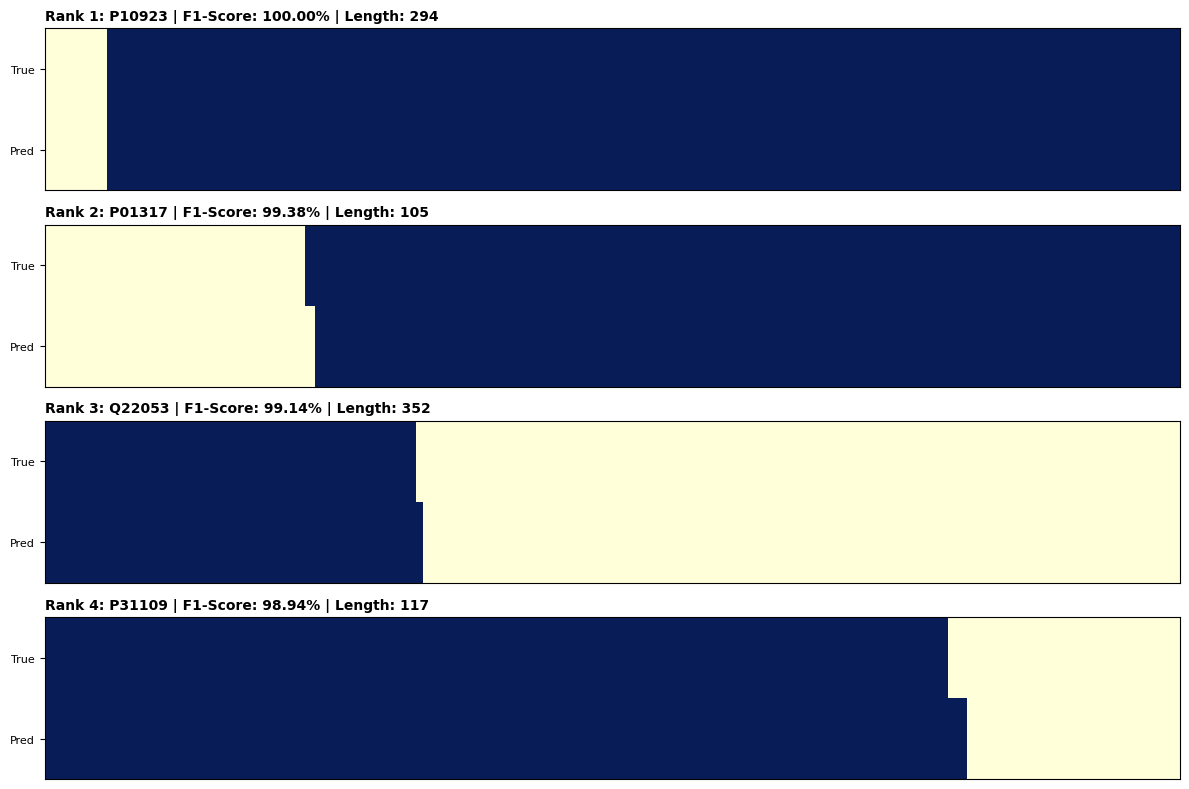

In [16]:
plot_consensus_heatmaps(external_test_data,y_test_pred_filtered, n_examples=4)

In [17]:
def moving_average_smoothing(y_probs, lengths, window_size=5):
    smoothed_probs = []
    start_idx = 0
    for length in lengths:
        end_idx = start_idx + length
        seq_probs = y_probs[start_idx:end_idx]
        window = np.ones(window_size) / window_size

        smoothed_seq = np.convolve(seq_probs, window, mode='same')
        
        smoothed_probs.append(smoothed_seq)
        start_idx = end_idx
    
    return np.concatenate(smoothed_probs)

y_test_probs_smoothed = moving_average_smoothing(test_probs_cat, test_lengths)
y_final = (y_test_probs_smoothed >= 0.5).astype(int)


In [18]:
from scipy.signal import savgol_filter

def savgol_smoothing(y_probs, lengths, window_size=11, polyorder=2):
    smoothed_list = []
    start_idx = 0
    for length in lengths:
        end_idx = start_idx + length
        seq_probs = y_probs[start_idx:end_idx]

        if len(seq_probs) > window_size:
            smoothed = savgol_filter(seq_probs, window_size, polyorder)
        else:
            smoothed = seq_probs 
            
        smoothed_list.append(smoothed)
        start_idx = end_idx
    return np.concatenate(smoothed_list)


In [19]:
def min_length_smoothing(y_pred, lengths, min_len=3):

    from itertools import groupby
    
    smoothed_preds = []
    start_idx = 0
    for length in lengths:
        seq = list(y_pred[start_idx:start_idx+length])
        groups = [(val, list(group)) for val, group in groupby(seq)]
        
        refined_seq = []
        for val, group in groups:
            if len(group) < min_len:
                refined_seq.extend([1 - val] * len(group))
            else:
                refined_seq.extend(group)
        
        smoothed_preds.append(np.array(refined_seq))
        start_idx += length
    return np.concatenate(smoothed_preds)


In [20]:
import numpy as np
from scipy.signal import convolve, savgol_filter
from itertools import groupby
from sklearn.metrics import classification_report


def apply_average_filter(y_probs, lengths, window_size=5):
    smoothed_probs = []
    start_idx = 0
    window = np.ones(window_size) / window_size
    for length in lengths:
        seq_probs = y_probs[start_idx:start_idx + length]
        smoothed_seq = np.convolve(seq_probs, window, mode='same')
        smoothed_probs.append(smoothed_seq)
        start_idx += length
    return np.concatenate(smoothed_probs)

def apply_savgol_filter(y_probs, lengths, window_size=7, polyorder=2):
    smoothed_probs = []
    start_idx = 0
    for length in lengths:
        seq_probs = y_probs[start_idx:start_idx + length]
        if length > window_size:
            smoothed = savgol_filter(seq_probs, window_size, polyorder)
        else:
            smoothed = seq_probs 
        smoothed_probs.append(smoothed)
        start_idx += length
    return np.concatenate(smoothed_probs)


def apply_min_length_constraint(y_pred, lengths, min_len=5):
    refined_preds = []
    start_idx = 0
    for length in lengths:
        seq = y_pred[start_idx:start_idx + length]
        # groupby 找出连续的 0 或 1 段
        groups = [(val, list(group)) for val, group in groupby(seq)]
        new_seq = []
        for val, group in groups:
            if len(group) < min_len:
                new_seq.extend([1 - val] * len(group))
            else:
                new_seq.extend(group)
        refined_preds.append(np.array(new_seq))
        start_idx += length
    return np.concatenate(refined_preds).astype(int)


probs_avg = apply_average_filter(test_probs_cat, test_lengths, window_size=5)
y_pred_avg = (probs_avg >= best_threshold_cat).astype(int)


probs_savgol = apply_savgol_filter(test_probs_cat, test_lengths, window_size=7, polyorder=2)
y_pred_savgol = (probs_savgol >= best_threshold_cat).astype(int)


y_pred_minlen = apply_min_length_constraint(y_test_pred_cat_final, test_lengths, min_len=5)


methods = [
    ("AVERAGE FILTER", y_pred_avg),
    ("SAVITZKY-GOLAY", y_pred_savgol),
    ("MIN LENGTH CONSTRAINT", y_pred_minlen)
]

for name, pred in methods:
    print("\n" + "="*60)
    print(f"CATBOOST + {name} PERFORMANCE")
    print("="*60)
    print(classification_report(y_test_ext, pred, target_names=['Ordered', 'Disordered']))



CATBOOST + AVERAGE FILTER PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.87      0.88    138695
  Disordered       0.49      0.54      0.51     31270

    accuracy                           0.81    169965
   macro avg       0.69      0.71      0.70    169965
weighted avg       0.82      0.81      0.81    169965


CATBOOST + SAVITZKY-GOLAY PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.87      0.88    138695
  Disordered       0.48      0.55      0.51     31270

    accuracy                           0.81    169965
   macro avg       0.69      0.71      0.70    169965
weighted avg       0.82      0.81      0.81    169965


CATBOOST + MIN LENGTH CONSTRAINT PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.90      0.87      0.88    138695
  Disordered       0.49      0.55      0.52     31270

    accuracy                           0.81    169965
   m

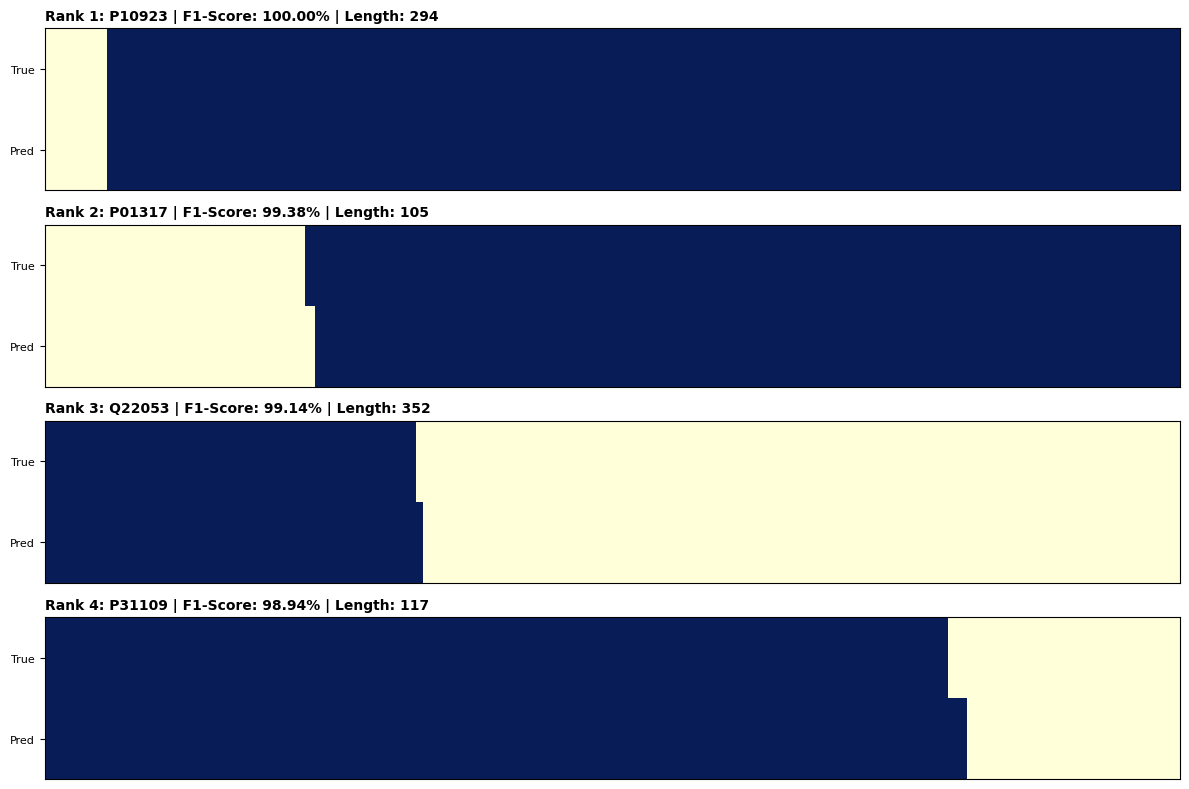

In [21]:
plot_consensus_heatmaps(external_test_data,y_test_pred_filtered, n_examples=4)

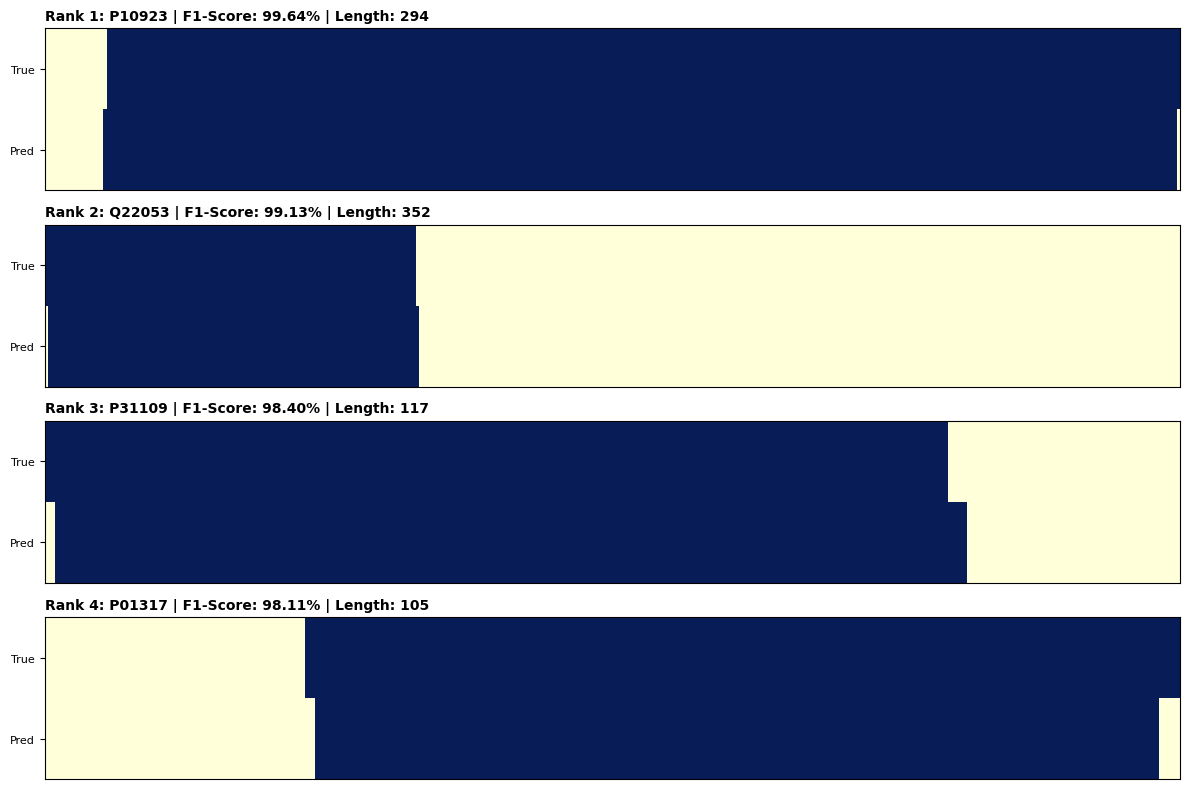

In [22]:
plot_consensus_heatmaps(external_test_data, y_pred_avg, n_examples=4) 

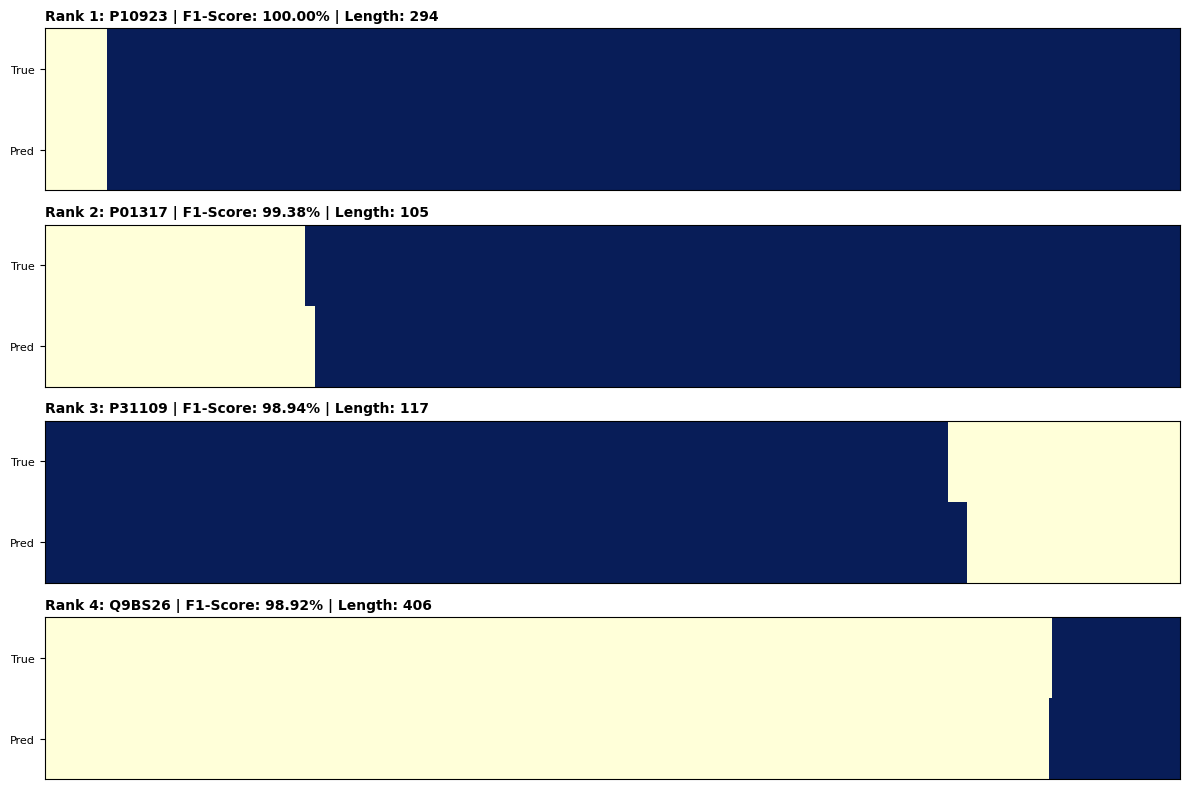

In [23]:
# Execute the visualization
plot_consensus_heatmaps(external_test_data, y_pred_savgol, n_examples=4) 

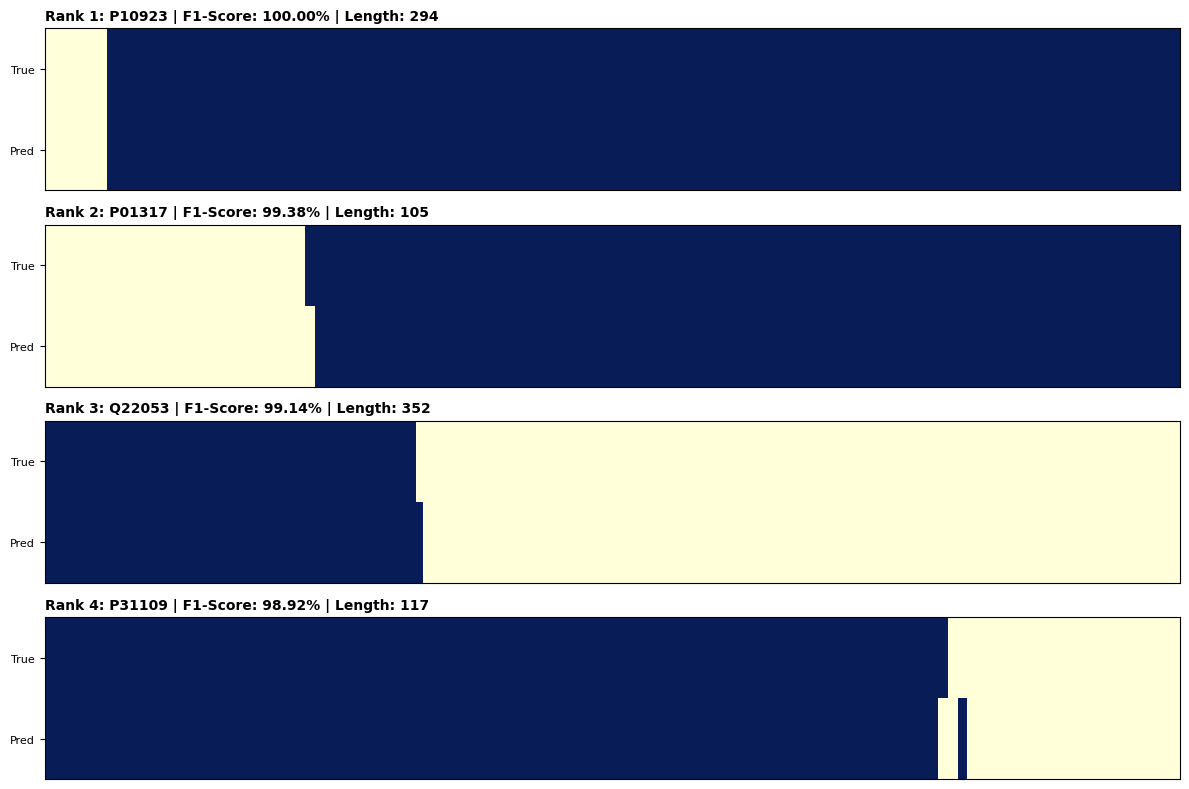

In [24]:
plot_consensus_heatmaps(external_test_data, y_pred_minlen, n_examples=4) 

In [25]:
import numpy as np
import json
from catboost import CatBoostClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# --- 1. USE THE ALIGNED GROUPS (Crucial Fix) ---
def create_groups_aligned(embeddings_dict, data_split):
    groups = []
    for i, kw in enumerate(data_split['kw']):
        if kw in embeddings_dict:
            actual_len = min(len(embeddings_dict[kw]), len(data_split['y'][i]))
            groups.extend([kw] * actual_len)
    return np.array(groups)

groups_train = create_groups_aligned(protein_embeddings, full_train_data)

# --- 2. Define Objective ---
def objective(params):
    params['depth'] = int(params['depth'])
    params['iterations'] = int(params['iterations'])
    
    gkf = GroupKFold(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        model = CatBoostClassifier(
            **params,
            task_type="GPU",
            devices='0',
            auto_class_weights='Balanced',
            random_seed=42,
            verbose=False,
            early_stopping_rounds=30
        )
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        preds = model.predict(X_val)
        cv_scores.append(f1_score(y_val, preds, average='macro'))
    
    return {'loss': -np.mean(cv_scores), 'status': STATUS_OK}

# --- 3. Run Optimization ---
space = {
    'iterations': hp.quniform('iterations', 400, 1000, 100),
    'depth': hp.quniform('depth', 4, 10, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'l2_leaf_reg': hp.uniform('l2_leaf_reg', 1, 10)
}

print("🚀 Starting Hyperopt...")
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

best['depth'] = int(best['depth'])
best['iterations'] = int(best['iterations'])
print(f"\n🏆 Best Params: {best}")

# --- 4. Final Training & Threshold Search ---
final_model = CatBoostClassifier(**best, task_type="GPU", auto_class_weights='Balanced', verbose=100)
final_model.fit(X_train, y_train)

# Search for best threshold on training set for Macro F1
train_probs = final_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.1, 0.9, 41)
best_t = 0.5
best_f1 = 0
for t in thresholds:
    score = f1_score(y_train, (train_probs >= t).astype(int), average='macro')
    if score > best_f1:
        best_f1, best_t = score, t

# --- 5. External Test ---
test_probs = final_model.predict_proba(X_test_ext)[:, 1]
y_test_pred = (test_probs >= best_t).astype(int)

print(f"\n🎯 Optimized Threshold: {best_t:.2f}")
print(classification_report(y_test_ext, y_test_pred, target_names=['Ordered', 'Disordered']))

# Save parameters
with open('best_params.json', 'w') as f:
    json.dump(best, f)



🚀 Starting Hyperopt...
100%|██████████| 10/10 [23:36<00:00, 141.68s/trial, best loss: -0.7141497628481347]

🏆 Best Params: {'depth': 9, 'iterations': 600, 'l2_leaf_reg': 5.696001800956726, 'learning_rate': 0.048277950375376556}
0:	learn: 0.6698240	total: 97.8ms	remaining: 58.6s
100:	learn: 0.4448218	total: 9.1s	remaining: 44.9s
200:	learn: 0.4335721	total: 17.9s	remaining: 35.6s
300:	learn: 0.4250172	total: 26.9s	remaining: 26.7s
400:	learn: 0.4176471	total: 35.6s	remaining: 17.7s
500:	learn: 0.4110855	total: 44.5s	remaining: 8.79s
599:	learn: 0.4050603	total: 53.2s	remaining: 0us

🎯 Optimized Threshold: 0.68
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.54      0.52     31270

    accuracy                           0.81    169965
   macro avg       0.70      0.71      0.70    169965
weighted avg       0.82      0.81      0.82    169965



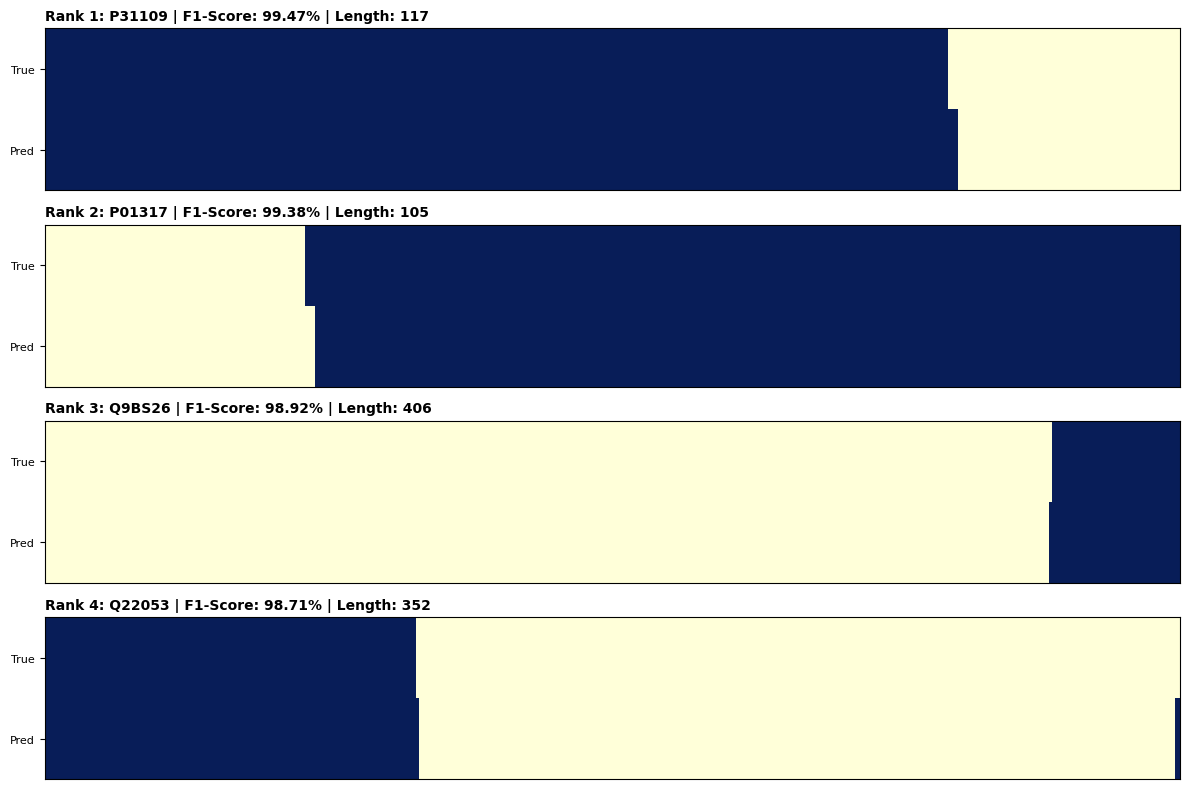

In [26]:
plot_consensus_heatmaps(external_test_data, y_test_pred, n_examples=4)

In [27]:
# Get lengths of proteins in the external test set
test_lengths = [len(labels) for labels in external_test_data['y']]

# Apply the filter (kernel_size=5 or 7 is standard for protein disorder)
y_test_pred_filtered = apply_per_protein_median_filter(
    y_test_pred, 
    test_lengths, 
    kernel_size=5
)

print("\n" + "="*60)
print("CATBOOST + MEDIAN FILTER PERFORMANCE")
print("="*60)
print(classification_report(y_test_ext, y_test_pred_filtered, target_names=['Ordered', 'Disordered']))


CATBOOST + MEDIAN FILTER PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.54      0.52     31270

    accuracy                           0.82    169965
   macro avg       0.70      0.71      0.70    169965
weighted avg       0.82      0.82      0.82    169965



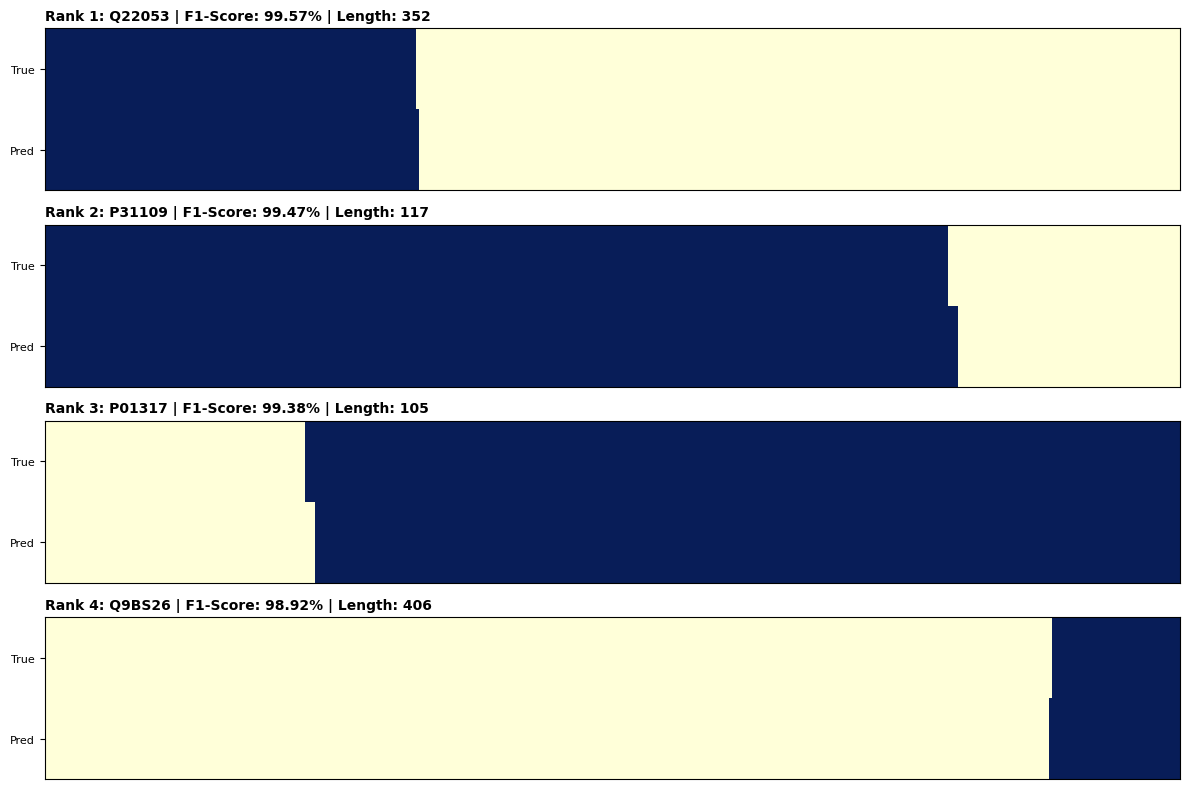

In [28]:
plot_consensus_heatmaps(external_test_data,y_test_pred_filtered, n_examples=4)

In [29]:
import numpy as np
from scipy.signal import convolve, savgol_filter
from itertools import groupby
from sklearn.metrics import classification_report


def apply_average_filter(y_probs, lengths, window_size=5):
    smoothed_probs = []
    start_idx = 0
    window = np.ones(window_size) / window_size
    for length in lengths:
        seq_probs = y_probs[start_idx:start_idx + length]
        smoothed_seq = np.convolve(seq_probs, window, mode='same')
        smoothed_probs.append(smoothed_seq)
        start_idx += length
    return np.concatenate(smoothed_probs)

def apply_savgol_filter(y_probs, lengths, window_size=7, polyorder=2):
    smoothed_probs = []
    start_idx = 0
    for length in lengths:
        seq_probs = y_probs[start_idx:start_idx + length]
        if length > window_size:
            smoothed = savgol_filter(seq_probs, window_size, polyorder)
        else:
            smoothed = seq_probs 
        smoothed_probs.append(smoothed)
        start_idx += length
    return np.concatenate(smoothed_probs)


def apply_min_length_constraint(y_pred, lengths, min_len=5):
    refined_preds = []
    start_idx = 0
    for length in lengths:
        seq = y_pred[start_idx:start_idx + length]
        # groupby 找出连续的 0 或 1 段
        groups = [(val, list(group)) for val, group in groupby(seq)]
        new_seq = []
        for val, group in groups:
            if len(group) < min_len:
                new_seq.extend([1 - val] * len(group))
            else:
                new_seq.extend(group)
        refined_preds.append(np.array(new_seq))
        start_idx += length
    return np.concatenate(refined_preds).astype(int)


probs_avg = apply_average_filter(test_probs, test_lengths, window_size=5)
y_pred_avg = (probs_avg >= best_t).astype(int)


probs_savgol = apply_savgol_filter(test_probs, test_lengths, window_size=7, polyorder=2)
y_pred_savgol = (probs_savgol >= best_t).astype(int)


y_pred_minlen = apply_min_length_constraint(y_test_pred, test_lengths, min_len=5)


methods = [
    ("AVERAGE FILTER", y_pred_avg),
    ("SAVITZKY-GOLAY", y_pred_savgol),
    ("MIN LENGTH CONSTRAINT", y_pred_minlen)
]

for name, pred in methods:
    print("\n" + "="*60)
    print(f"CATBOOST + {name} PERFORMANCE")
    print("="*60)
    print(classification_report(y_test_ext, pred, target_names=['Ordered', 'Disordered']))



CATBOOST + AVERAGE FILTER PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.53      0.52     31270

    accuracy                           0.82    169965
   macro avg       0.70      0.71      0.70    169965
weighted avg       0.82      0.82      0.82    169965


CATBOOST + SAVITZKY-GOLAY PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.54      0.52     31270

    accuracy                           0.82    169965
   macro avg       0.70      0.71      0.70    169965
weighted avg       0.82      0.82      0.82    169965


CATBOOST + MIN LENGTH CONSTRAINT PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.54      0.52     31270

    accuracy                           0.82    169965
   m

In [30]:
# Save the model file
final_model.save_model("F:/final_catboost_protein_model.cbm")
print("✅ CatBoost Model saved to F: drive")

✅ CatBoost Model saved to F: drive


In [31]:

import lightgbm as lgb
import os

# --- 1. Define LGBM Objective ---
def objective_lgbm(params):
    params['num_leaves'] = int(params['num_leaves'])
    params['max_depth'] = int(params['max_depth'])
    params['n_estimators'] = int(params['n_estimators'])
    
    gkf = GroupKFold(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
        # LightGBM uses 'is_unbalance' or 'scale_pos_weight' for imbalance
        model = lgb.LGBMClassifier(
            **params,
            device="gpu",
            is_unbalance=True, 
            random_state=42,
            verbosity=-1
        )
        
        model.fit(
            X_train[train_idx], y_train[train_idx],
            eval_set=[(X_train[val_idx], y_train[val_idx])],
            callbacks=[lgb.early_stopping(stopping_rounds=30)]
        )
        
        preds = model.predict(X_train[val_idx])
        cv_scores.append(f1_score(y_train[val_idx], preds, average='macro'))
    
    return {'loss': -np.mean(cv_scores), 'status': STATUS_OK}

# --- 2. LGBM Search Space ---
space_lgbm = {
    'n_estimators': hp.quniform('n_estimators', 400, 1000, 100),
    'num_leaves': hp.quniform('num_leaves', 31, 255, 1),
    'max_depth': hp.quniform('max_depth', 4, 12, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'lambda_l1': hp.uniform('lambda_l1', 0, 10),
    'lambda_l2': hp.uniform('lambda_l2', 0, 10)
}

print("🚀 Starting LightGBM Hyperopt...")
trials_lgbm = Trials()
best_lgbm = fmin(fn=objective_lgbm, space=space_lgbm, algo=tpe.suggest, max_evals=10, trials=trials_lgbm)

# --- 3. Final LGBM Training & Threshold Search ---
best_lgbm_params = {
    **best_lgbm, 
    'num_leaves': int(best_lgbm['num_leaves']),
    'max_depth': int(best_lgbm['max_depth']),
    'n_estimators': int(best_lgbm['n_estimators'])
}

final_lgbm = lgb.LGBMClassifier(**best_lgbm_params, device="gpu", is_unbalance=True)
final_lgbm.fit(X_train, y_train)

# Threshold Search
train_probs_lgbm = final_lgbm.predict_proba(X_train)[:, 1]
best_t_lgbm = 0.5
best_f1_lgbm = 0
for t in np.linspace(0.1, 0.9, 41):
    score = f1_score(y_train, (train_probs_lgbm >= t).astype(int), average='macro')
    if score > best_f1_lgbm:
        best_f1_lgbm, best_t_lgbm = score, t

# --- 4. Final Evaluation & Save ---
test_probs_lgbm = final_lgbm.predict_proba(X_test_ext)[:, 1]
print(f"\n🎯 LGBM Optimized Threshold: {best_t_lgbm:.2f}")
print(classification_report(y_test_ext, (test_probs_lgbm >= best_t_lgbm).astype(int)))

final_lgbm.booster_.save_model("F:/final_lgbm_protein_model.txt")

🚀 Starting LightGBM Hyperopt...
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:                    
[45]	valid_0's binary_logloss: 0.417969
  0%|          | 0/10 [00:18<?, ?trial/s, best loss=?]

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:                    
[54]	valid_0's binary_logloss: 0.420977
  0%|          | 0/10 [00:39<?, ?trial/s, best loss=?]

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:                    
[46]	valid_0's binary_logloss: 0.422548
  0%|          | 0/10 [00:59<?, ?trial/s, best loss=?]

...

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Training until validation scores don't improve for 30 rounds                      
Early stopping, best iteration is:                                                
[4]	valid_0's binary_logloss: 0.427225
100%|██████████| 10/10 [14:47<00:00, 88.77s/trial, best loss: -0.7371374033784193]

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



🎯 LGBM Optimized Threshold: 0.68
              precision    recall  f1-score   support

           0       0.89      0.88      0.89    138695
           1       0.50      0.53      0.51     31270

    accuracy                           0.81    169965
   macro avg       0.70      0.71      0.70    169965
weighted avg       0.82      0.81      0.82    169965



In [32]:
y_test_pred_lgbm = (test_probs_lgbm >= best_t_lgbm).astype(int)

In [34]:
# Get lengths of proteins in the external test set
test_lengths = [len(labels) for labels in external_test_data['y']]

# Apply the filter (kernel_size=5 or 7 is standard for protein disorder)
y_test_pred_filtered = apply_per_protein_median_filter(
    y_test_pred_lgbm, 
    test_lengths, 
    kernel_size=5
)

print("\n" + "="*60)
print("LGBM + MEDIAN FILTER PERFORMANCE")
print("="*60)
print(classification_report(y_test_ext, y_test_pred_filtered, target_names=['Ordered', 'Disordered']))


LGBM + MEDIAN FILTER PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.53      0.52     31270

    accuracy                           0.82    169965
   macro avg       0.70      0.71      0.70    169965
weighted avg       0.82      0.82      0.82    169965



In [35]:
import numpy as np
from scipy.signal import convolve, savgol_filter
from itertools import groupby
from sklearn.metrics import classification_report


def apply_average_filter(y_probs, lengths, window_size=5):
    smoothed_probs = []
    start_idx = 0
    window = np.ones(window_size) / window_size
    for length in lengths:
        seq_probs = y_probs[start_idx:start_idx + length]
        smoothed_seq = np.convolve(seq_probs, window, mode='same')
        smoothed_probs.append(smoothed_seq)
        start_idx += length
    return np.concatenate(smoothed_probs)

def apply_savgol_filter(y_probs, lengths, window_size=7, polyorder=2):
    smoothed_probs = []
    start_idx = 0
    for length in lengths:
        seq_probs = y_probs[start_idx:start_idx + length]
        if length > window_size:
            smoothed = savgol_filter(seq_probs, window_size, polyorder)
        else:
            smoothed = seq_probs 
        smoothed_probs.append(smoothed)
        start_idx += length
    return np.concatenate(smoothed_probs)


def apply_min_length_constraint(y_pred, lengths, min_len=5):
    refined_preds = []
    start_idx = 0
    for length in lengths:
        seq = y_pred[start_idx:start_idx + length]
        groups = [(val, list(group)) for val, group in groupby(seq)]
        new_seq = []
        for val, group in groups:
            if len(group) < min_len:
                new_seq.extend([1 - val] * len(group))
            else:
                new_seq.extend(group)
        refined_preds.append(np.array(new_seq))
        start_idx += length
    return np.concatenate(refined_preds).astype(int)


probs_avg = apply_average_filter(test_probs_lgbm, test_lengths, window_size=5)
y_pred_avg = (probs_avg >= best_t_lgbm).astype(int)


probs_savgol = apply_savgol_filter(test_probs_lgbm, test_lengths, window_size=7, polyorder=2)
y_pred_savgol = (probs_savgol >= best_t_lgbm).astype(int)


y_pred_minlen = apply_min_length_constraint(y_test_pred_lgbm, test_lengths, min_len=5)


methods = [
    ("AVERAGE FILTER", y_pred_avg),
    ("SAVITZKY-GOLAY", y_pred_savgol),
    ("MIN LENGTH CONSTRAINT", y_pred_minlen)
]

for name, pred in methods:
    print("\n" + "="*60)
    print(f"LGBM + {name} PERFORMANCE")
    print("="*60)
    print(classification_report(y_test_ext, pred, target_names=['Ordered', 'Disordered']))


LGBM + AVERAGE FILTER PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.51      0.52      0.52     31270

    accuracy                           0.82    169965
   macro avg       0.70      0.70      0.70    169965
weighted avg       0.82      0.82      0.82    169965


LGBM + SAVITZKY-GOLAY PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.53      0.52     31270

    accuracy                           0.82    169965
   macro avg       0.70      0.71      0.70    169965
weighted avg       0.82      0.82      0.82    169965


LGBM + MIN LENGTH CONSTRAINT PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.53      0.52     31270

    accuracy                           0.82    169965
   macro avg    

In [38]:
import xgboost as xgb
import numpy as np
import os
import json
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# --- 0. Pre-calculate Class Imbalance Ratio ---
# ratio = count(majority) / count(minority)
imbalance_ratio = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"Detected Imbalance Ratio: {imbalance_ratio:.2f}")


def objective_xgb(params):
    params['max_depth'] = int(params['max_depth'])
    params['n_estimators'] = int(params['n_estimators'])
    
    gkf = GroupKFold(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
        dtrain = xgb.DMatrix(X_train[train_idx], label=y_train[train_idx])
        dval = xgb.DMatrix(X_train[val_idx], label=y_train[val_idx])
        
        model = xgb.XGBClassifier(
            **params,
            tree_method="hist", 
            device="cuda", 
            scale_pos_weight=imbalance_ratio,
            random_state=42,
            eval_metric="logloss",
            early_stopping_rounds=30
        )
        
        model.fit(
            X_train[train_idx], y_train[train_idx],
            eval_set=[(X_train[val_idx], y_train[val_idx])],
            verbose=False
        )
        
        preds = model.predict(X_train[val_idx])
        cv_scores.append(f1_score(y_train[val_idx], preds, average='macro'))
    
    return {'loss': -np.mean(cv_scores), 'status': STATUS_OK}


# --- 2. XGBoost Search Space ---
space_xgb = {
    'n_estimators': hp.quniform('n_estimators', 400, 1000, 100),
    'max_depth': hp.quniform('max_depth', 4, 10, 1), # Keep depth <= 10 for memory safety
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'gamma': hp.uniform('gamma', 0, 5),          # Complexity control
    'reg_alpha': hp.uniform('reg_alpha', 0, 10),  # L1
    'reg_lambda': hp.uniform('reg_lambda', 0, 10) # L2
}

# --- 3. Run Optimization ---
print("🚀 Starting XGBoost Hyperopt with 5-Fold GroupCV...")
trials_xgb = Trials()
best_xgb = fmin(
    fn=objective_xgb, 
    space=space_xgb, 
    algo=tpe.suggest, 
    max_evals=10, 
    trials=trials_xgb
)

# Convert best params back to integers
best_xgb_params = {
    **best_xgb, 
    'max_depth': int(best_xgb['max_depth']),
    'n_estimators': int(best_xgb['n_estimators'])
}
print(f"\n🏆 Best XGBoost Params: {best_xgb_params}")

# --- 4. Final Training on Full Training Set ---
print("\nTraining final XGBoost model...")
final_xgb = xgb.XGBClassifier(
    **best_xgb_params, 
    tree_method="hist", 
    device="cuda",
    scale_pos_weight=imbalance_ratio
)
final_xgb.fit(X_train, y_train)

# --- 5. Threshold Optimization for Macro F1 ---
print("Searching for optimal threshold...")
train_probs_xgb = final_xgb.predict_proba(X_train)[:, 1]
best_t_xgb = 0.5
best_f1_xgb = 0
for t in np.linspace(0.1, 0.9, 41):
    score = f1_score(y_train, (train_probs_xgb >= t).astype(int), average='macro')
    if score > best_f1_xgb:
        best_f1_xgb, best_t_xgb = score, t

# --- 6. External Test Set Evaluation ---
test_probs_xgb = final_xgb.predict_proba(X_test_ext)[:, 1]
y_test_pred_xgb = (test_probs_xgb >= best_t_xgb).astype(int)

print(f"\n🎯 XGBoost Optimized Threshold: {best_t_xgb:.2f}")
print("="*60)
print("XGBOOST - FINAL EXTERNAL PERFORMANCE")
print("="*60)
print(classification_report(y_test_ext, y_test_pred_xgb, target_names=['Ordered', 'Disordered']))


Detected Imbalance Ratio: 4.04
🚀 Starting XGBoost Hyperopt with 5-Fold GroupCV...
100%|██████████| 10/10 [1:49:06<00:00, 654.67s/trial, best loss: -0.730991430042073]

🏆 Best XGBoost Params: {'gamma': 1.733263400221396, 'learning_rate': 0.10112390066215005, 'max_depth': 9, 'n_estimators': 800, 'reg_alpha': 7.547492822804825, 'reg_lambda': 1.601067541564306}

Training final XGBoost model...
Searching for optimal threshold...

🎯 XGBoost Optimized Threshold: 0.66
XGBOOST - FINAL EXTERNAL PERFORMANCE
              precision    recall  f1-score   support

     Ordered       0.89      0.89      0.89    138695
  Disordered       0.51      0.51      0.51     31270

    accuracy                           0.82    169965
   macro avg       0.70      0.70      0.70    169965
weighted avg       0.82      0.82      0.82    169965



TypeError: `_estimator_type` undefined.  Please use appropriate mixin to define estimator type.

In [39]:
# --- 7. Save Model and Metadata ---
# 使用 get_booster() 避免 Scikit-learn 介面的 _estimator_type 錯誤
final_xgb.get_booster().save_model("F:/final_xgb_protein_model.json")

metadata_xgb = {
    "best_threshold": float(best_t_xgb),  # 確保為原生 float 以免 json 報錯
    "best_params": best_xgb_params,
    "imbalance_ratio": float(imbalance_ratio)
}

with open("F:/xgb_metadata.json", "w") as f:
    json.dump(metadata_xgb, f, indent=4)

print("\n✅ XGBoost Workflow Complete. Model saved to F: drive.")



✅ XGBoost Workflow Complete. Model saved to F: drive.


In [40]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, f1_score

print("🚀 Starting Ensemble Voting (CatBoost + LightGBM + XGBoost)...")

# --- 1. Get Probabilities from all models ---
# Ensure you use the specific best_t found for each model earlier
# If you don't have them in memory, use the values from your printed logs
prob_cat = final_model.predict_proba(X_test_ext)[:, 1]
prob_lgbm = final_lgbm.predict_proba(X_test_ext)[:, 1]
prob_xgb = final_xgb.predict_proba(X_test_ext)[:, 1]

# --- 2. Generate Individual Predictions (using their specific thresholds) ---
pred_cat = (prob_cat >= best_t).astype(int)
pred_lgbm = (prob_lgbm >= best_t_lgbm).astype(int)
pred_xgb = (prob_xgb >= best_t_xgb).astype(int)

# --- 3. Hard Voting (Majority Rule) ---
# Sum the binary predictions; if sum is >= 2, the majority predicted 'Disordered' (1)
combined_hard = pred_cat + pred_lgbm + pred_xgb
y_hard_voting = (combined_hard >= 2).astype(int)

# --- 4. Soft Voting (Weighted Average Probabilities) ---
# We average the raw probabilities and find a new optimal threshold for the ensemble
avg_prob = (prob_cat + prob_lgbm + prob_xgb) / 3

# Search for the best ensemble threshold on the external set (or a validation set)
best_t_ensemble = 0.5
best_f1_ensemble = 0
for t in np.linspace(0.1, 0.9, 81):
    score = f1_score(y_test_ext, (avg_prob >= t).astype(int), average='macro')
    if score > best_f1_ensemble:
        best_f1_ensemble = score
        best_t_ensemble = t

y_soft_voting = (avg_prob >= best_t_ensemble).astype(int)

# --- 5. Compare Results ---
print("\n" + "="*30)
print("ENSEMBLE: HARD VOTING")
print("="*30)
print(classification_report(y_test_ext, y_hard_voting, target_names=['Ordered', 'Disordered']))

print("\n" + "="*30)
print(f"ENSEMBLE: SOFT VOTING (Threshold: {best_t_ensemble:.2f})")
print("="*30)
print(classification_report(y_test_ext, y_soft_voting, target_names=['Ordered', 'Disordered']))

# --- 6. Save Ensemble Predictions ---
ensemble_results = pd.DataFrame({
    'UniProt_ACC': external_test_data['kw_flat'] if 'kw_flat' in locals() else "unknown",
    'Soft_Prob': avg_prob,
    'Ensemble_Pred': y_soft_voting
})
ensemble_results.to_csv("F:/ensemble_final_predictions.csv", index=False)
print("\n✅ Ensemble Workflow Complete. Results saved to F: drive.")


🚀 Starting Ensemble Voting (CatBoost + LightGBM + XGBoost)...


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



ENSEMBLE: HARD VOTING
              precision    recall  f1-score   support

     Ordered       0.89      0.88      0.89    138695
  Disordered       0.50      0.53      0.52     31270

    accuracy                           0.82    169965
   macro avg       0.70      0.71      0.70    169965
weighted avg       0.82      0.82      0.82    169965


ENSEMBLE: SOFT VOTING (Threshold: 0.68)
              precision    recall  f1-score   support

     Ordered       0.89      0.89      0.89    138695
  Disordered       0.52      0.51      0.52     31270

    accuracy                           0.82    169965
   macro avg       0.71      0.70      0.70    169965
weighted avg       0.82      0.82      0.82    169965


✅ Ensemble Workflow Complete. Results saved to F: drive.
